In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [2]:
home= "Ipswich Town"
away= "Wolves"

In [3]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Ipswich Town,Tottenham,2025-02-22,L,H,1,4,-3,1,0,...,1.0,0.6,-0.1,-0.1,0.0,0.07,1,2.7,0.44,-1.3
26,Ipswich Town,Manchester Utd,2025-02-26,L,A,2,3,-1,2,0,...,0.3,0.5,0.6,0.6,0.7,0.12,0,1.5,0.31,-0.5
27,Ipswich Town,Crystal Palace,2025-03-08,L,A,0,1,-1,0,0,...,0.7,0.4,-1.5,-1.5,-0.7,0.13,0,1.3,0.32,0.3
28,Ipswich Town,Nott'ham Forest,2025-03-15,L,H,2,4,-2,2,0,...,0.3,0.4,1.6,1.6,1.7,0.04,1,2.7,0.44,-1.3
29,Ipswich Town,Bournemouth,2025-04-02,W,A,2,1,1,2,0,...,1.1,0.5,0.8,0.8,0.9,0.12,0,0.9,0.17,-0.1


In [4]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Tottenham,Ipswich Town,2025-02-22,W,A,4,1,3,4,0,...,1.5,0.5,2.3,2.3,2.5,0.17,0,0.7,0.14,-0.3
26,Manchester Utd,Ipswich Town,2025-02-26,W,H,3,2,1,2,0,...,0.3,0.4,1.3,1.3,0.7,0.08,0,1.4,0.46,-0.6
27,Crystal Palace,Ipswich Town,2025-03-08,W,H,1,0,1,1,0,...,2.2,1.6,-2.2,-2.2,-2.2,0.17,1,1.6,0.27,1.6
28,Nott'ham Forest,Ipswich Town,2025-03-15,W,A,4,2,2,4,0,...,1.3,0.6,2.5,2.5,1.7,0.14,0,0.5,0.16,-1.5
29,Bournemouth,Ipswich Town,2025-04-02,L,H,1,2,-1,1,0,...,0.7,0.7,-0.8,-0.8,-0.7,0.08,0,0.8,0.40,-1.2


In [5]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Wolves,Bournemouth,2025-02-22,W,A,1,0,1,1,0,...,1.7,0.7,-1.0,-1.0,-0.7,0.15,1,0.6,0.19,0.6
26,Wolves,Fulham,2025-02-25,L,H,1,2,-1,1,0,...,0.9,0.9,-0.3,-0.3,0.1,0.07,3,1.7,0.35,-0.3
27,Wolves,Everton,2025-03-08,D,H,1,1,0,1,0,...,0.7,0.6,0.2,0.2,0.3,0.07,1,1.5,0.37,0.5
28,Wolves,Southampton,2025-03-15,W,A,2,1,1,2,0,...,0.4,0.3,1.6,1.6,1.6,0.07,0,1.8,0.62,0.8
29,Wolves,West Ham,2025-04-01,W,H,1,0,1,1,0,...,1.1,0.6,-0.2,-0.2,-1.1,0.13,1,0.2,0.22,0.2


In [6]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Bournemouth,Wolves,2025-02-22,L,H,0,1,-1,0,0,...,0.8,0.6,-0.9,-0.9,-0.8,0.11,0,1.4,0.27,0.4
26,Fulham,Wolves,2025-02-25,W,A,2,1,1,2,0,...,1.5,0.8,0.3,0.3,0.5,0.15,0,0.4,0.09,-0.6
27,Everton,Wolves,2025-03-08,D,A,1,1,0,1,0,...,1.2,0.7,-0.2,-0.2,-0.2,0.12,0,1.1,0.37,0.1
28,Southampton,Wolves,2025-03-15,L,H,1,2,-1,1,0,...,0.7,1.1,-0.3,-0.3,-0.7,0.14,0,0.9,0.31,-1.1
29,West Ham,Wolves,2025-04-01,L,A,0,1,-1,0,0,...,1.0,0.9,-1.3,-1.3,-1.0,0.13,2,0.7,0.35,-0.3


In [7]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'GF', 'GA', 'GD', 'G-PK', 'PK', 'PKatt', 'PKm', 'Poss', 'Att (GK)', 'Thr', 'Pa Launch%', 'Pa AvgLen', 'Won', 'Lost', 'Won%', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 'PrgC', 'Last3rd Car', 'OppCr', 'Stp', 'Stp%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'GK Att', 'Launch%', 'AvgLen', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'PKcon', 'OG', 'Recov', '#OPA', 'AvgDist', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'PKdef', 'PKA', 'PKms', 'Missed PK%', 'PKAg', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassL

# Desc

# Features

## Offense

In [8]:
offense= ['G-PK', 'PK', 'PKm', 'Poss', 'PKatt', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 
          'PrgC', 'Last3rd Car', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'Sh', 'G/Sh', 
          'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 
          'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 
          'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 
          'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassLive Sc', 'PassDead Sc', 'TO Sc', 'Sh-Sh', 
          'Fld Sc', 'Def-Sc', 'Touches', 'Def Pen', 'Tch Def 3rd', 'Tch Mid 3rd', 'Tch Att 3rd', 'Att Pen', 'Live Tch', 'xG', 
          'npxG', 'xGD', 'npxGD', 'xAG', 'xA', 'G-xG', 'np:G-xG', 'A-xAG', 'npxG/Sh', 'FKAtt', 'GF']

In [9]:
df_home_off= df_home[offense]
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,1,0,0,42,0,15,5,33.3,9,60.0,...,-0.5,-0.5,1.0,0.6,-0.1,-0.1,0.0,0.07,1,1
26,2,0,0,55,0,15,5,33.3,9,60.0,...,0.7,0.7,0.3,0.5,0.6,0.6,0.7,0.12,0,2
27,0,0,0,45,0,26,10,38.5,10,38.5,...,-1.7,-1.7,0.7,0.4,-1.5,-1.5,-0.7,0.13,0,0
28,2,0,0,55,0,17,9,52.9,6,35.3,...,-1.1,-1.1,0.3,0.4,1.6,1.6,1.7,0.04,1,2
29,2,0,0,37,0,15,8,53.3,7,46.7,...,-0.7,-0.7,1.1,0.5,0.8,0.8,0.9,0.12,0,2


In [10]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,4,0,0,58,0,20,5,25.0,12,60.0,...,0.5,0.5,1.5,0.5,2.3,2.3,2.5,0.17,0,4
26,2,0,0,45,0,21,7,33.3,12,57.1,...,-0.7,-0.7,0.3,0.4,1.3,1.3,0.7,0.08,0,3
27,1,0,0,55,0,19,9,47.4,7,36.8,...,1.7,1.7,2.2,1.6,-2.2,-2.2,-2.2,0.17,1,1
28,4,0,0,45,0,8,4,50.0,4,50.0,...,1.1,1.1,1.3,0.6,2.5,2.5,1.7,0.14,0,4
29,1,0,0,63,0,13,4,30.8,9,69.2,...,0.7,0.7,0.7,0.7,-0.8,-0.8,-0.7,0.08,0,1


In [11]:
df_away_off= df_away[offense]
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,1,0,0,54,0,15,9,60.0,3,20.0,...,1.1,1.1,1.7,0.7,-1.0,-1.0,-0.7,0.15,1,1
26,1,0,0,60,0,24,10,41.7,10,41.7,...,-0.4,-0.4,0.9,0.9,-0.3,-0.3,0.1,0.07,3,1
27,1,0,0,66,0,16,6,37.5,10,62.5,...,-0.5,-0.5,0.7,0.6,0.2,0.2,0.3,0.07,1,1
28,2,0,0,40,0,13,4,30.8,7,53.8,...,-1.0,-1.0,0.4,0.3,1.6,1.6,1.6,0.07,0,2
29,1,0,0,42,0,21,8,38.1,11,52.4,...,-0.2,-0.2,1.1,0.6,-0.2,-0.2,-1.1,0.13,1,1


In [12]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,0,0,0,46,0,32,11,34.4,16,50.0,...,-1.1,-1.1,0.8,0.6,-0.9,-0.9,-0.8,0.11,0,0
26,2,0,0,40,0,14,6,42.9,6,42.9,...,0.4,0.4,1.5,0.8,0.3,0.3,0.5,0.15,0,2
27,1,0,0,34,0,9,5,55.6,4,44.4,...,0.5,0.5,1.2,0.7,-0.2,-0.2,-0.2,0.12,0,1
28,1,0,0,60,0,37,18,48.6,12,32.4,...,1.0,1.0,0.7,1.1,-0.3,-0.3,-0.7,0.14,0,1
29,0,0,0,58,0,16,2,12.5,11,68.8,...,0.2,0.2,1.0,0.9,-1.3,-1.3,-1.0,0.13,2,0


## Defence

In [13]:
defence= ['OppCr', 'Stp', 'Stp%', 'PKcon', '#OPA', 'AvgDist', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'SoTA', 'Saves', 
          'Save%', 'Tkl', 'TklW', 'Tkl Def 3rd', 'Tkl Mid 3rd', 'Tkl Att 3rd', 'Tkl.2', 'Tkl Att', 'Tkl%', 'Lost Tkl', 
          'Ints', 'BlcSh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err',  'PSxG', 'PSxG/SoT', 'PSxG+/-', 'GA']

In [14]:
df_home_def= df_home[defence]
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
25,4,0,0.0,0,0,4.5,0,NaN,0,0,...,3,4,10,33,10,0,2.7,0.44,-1.3,4
26,13,2,15.4,0,3,16.6,0,NaN,0,2,...,3,3,11,27,24,2,1.5,0.31,-0.5,3
27,17,2,11.8,0,0,8.2,0,NaN,0,0,...,9,13,8,22,37,2,1.3,0.32,0.3,1
28,10,1,10.0,0,3,16.4,0,NaN,0,1,...,1,11,4,14,22,1,2.7,0.44,-1.3,4
29,35,3,8.6,0,2,12.3,0,NaN,0,0,...,8,6,6,20,56,1,0.9,0.17,-0.1,1


In [15]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
25,15,1,6.7,0,1,15.0,0,NaN,0,0,...,6,8,6,23,17,2,0.7,0.14,-0.3,1
26,16,1,6.3,0,0,8.0,0,NaN,0,0,...,5,8,4,22,26,1,1.4,0.46,-0.6,2
27,14,0,0.0,0,1,7.8,0,NaN,0,0,...,4,9,7,30,40,2,1.6,0.27,1.6,0
28,15,0,0.0,0,0,2.0,0,NaN,0,0,...,3,1,3,18,36,1,0.5,0.16,-1.5,2
29,7,1,14.3,0,4,18.1,0,NaN,0,0,...,2,13,9,25,21,1,0.8,0.40,-1.2,2


In [16]:
df_away_def= df_away[defence]
df_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,11,1,9.1,0,2,15.8,0,NaN,0,0,...,6,7,7,26,13,0,1.7,0.28,-0.3,2
1,8,0,0.0,0,3,21.2,0,NaN,0,1,...,3,10,9,28,20,0,3.0,0.40,-3.0,6
2,17,1,5.9,0,1,11.0,0,NaN,0,1,...,6,8,10,33,27,0,1.7,0.35,0.7,1
3,10,1,10.0,0,1,10.0,0,NaN,0,0,...,4,8,10,33,20,0,1.7,0.29,-0.3,2
4,12,0,0.0,0,1,19.5,0,NaN,0,0,...,4,9,10,33,21,0,1.8,0.59,-1.2,3


In [17]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,11,1,9.1,0,0,9.0,0,NaN,0,0,...,1,5,8,26,16,2,0.2,0.06,0.2,0
1,8,2,25.0,0,2,15.7,0,NaN,0,0,...,2,9,9,23,20,2,0.8,0.19,-1.2,2
2,6,0,0.0,0,0,5.7,0,NaN,0,0,...,3,6,10,27,13,0,0.6,0.29,-0.4,1
3,13,1,7.7,0,2,17.0,0,NaN,0,0,...,1,9,5,19,25,1,1.3,0.25,0.3,1
4,10,0,0.0,0,2,16.3,0,NaN,0,0,...,5,6,5,20,15,1,1.1,0.28,0.1,1


## Combined

In [18]:
combined= ['Won', 'Lost', 'Won%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Recov']

In [19]:
df_home_cmb= df_home[combined]
df_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,4,7,36.4,2,0,0,15,14,44
26,14,10,58.3,4,0,0,16,9,39
27,22,21,51.2,3,0,0,7,8,46
28,12,14,46.2,1,0,0,4,13,36
29,15,19,44.1,2,0,0,15,14,43


In [20]:
df_vs_home_cmb= df_vs_home[combined]
df_vs_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,7,4,63.6,1,0,0,14,15,47
26,10,14,41.7,4,1,0,9,16,43
27,21,22,48.8,4,0,0,8,7,46
28,14,12,53.8,1,0,0,13,3,38
29,19,15,55.9,1,0,0,14,15,56


In [21]:
df_away_cmb= df_away[combined]
df_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,17,16,51.5,3,0,0,9,17,48
26,12,18,40.0,1,0,0,8,15,42
27,9,15,37.5,2,0,0,11,16,43
28,14,12,53.8,0,0,0,13,9,47
29,9,11,45.0,4,0,0,16,12,43


In [22]:
df_vs_away_cmb= df_vs_away[combined]
df_vs_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,16,17,48.5,3,1,0,17,8,56
26,18,12,60.0,3,0,0,15,8,36
27,15,9,62.5,2,0,0,16,10,35
28,12,14,46.2,0,0,0,12,13,41
29,11,9,55.0,2,0,0,12,16,37


## By Team

In [23]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    #for col in target_cols:
     #   for lag in range(1, window+1):
      #      df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [24]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,1,0,0,42,0,15,5,33.3,9,60.0,...,-0.050,0.704746,0.025,0.727438,0.1075,0.042720,0.75,0.957427,0.75,0.500000
26,2,0,0,55,0,15,5,33.3,9,60.0,...,0.050,0.645497,0.150,0.645497,0.1100,0.039158,1.00,0.816497,1.00,0.000000
27,0,0,0,45,0,26,10,38.5,10,38.5,...,0.075,0.670199,0.175,0.670199,0.1000,0.024495,1.00,0.816497,1.25,0.500000
28,2,0,0,55,0,17,9,52.9,6,35.3,...,-0.100,0.989949,0.175,0.670199,0.1025,0.027538,0.50,0.577350,1.00,0.816497
29,2,0,0,37,0,15,8,53.3,7,46.7,...,0.150,1.302562,0.425,1.024288,0.0900,0.042426,0.50,0.577350,1.25,0.957427


In [25]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,4,0,0,58,0,20,5,25.0,12,60.0,...,1.175000e+00,1.883923,0.475,1.776467,0.1300,0.038297,0.50,1.000000,3.25,2.217356
26,2,0,0,45,0,21,7,33.3,12,57.1,...,1.000000e+00,1.679286,0.500,1.812917,0.1275,0.034034,0.50,1.000000,2.75,1.500000
27,1,0,0,55,0,19,9,47.4,7,36.8,...,8.250000e-01,1.573478,0.325,1.728921,0.1125,0.039476,0.50,1.000000,2.50,1.290994
28,4,0,0,45,0,8,4,50.0,4,50.0,...,-1.110223e-16,2.143206,-0.150,2.164101,0.1300,0.046904,0.75,0.957427,2.25,1.500000
29,1,0,0,63,0,13,4,30.8,9,69.2,...,9.750000e-01,2.180787,0.675,2.053249,0.1400,0.042426,0.25,0.500000,3.00,1.414214


In [26]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,22,3,13.6,0,4,14.1,0,0.0,0,0,...,0.25,0.500000,1.55,1.276715,0.3000,0.177388,0.05,0.602771,1.50,1.290994
26,7,0,0.0,0,1,30.0,0,0.0,0,0,...,1.00,1.414214,0.85,0.369685,0.2075,0.039476,0.10,0.648074,0.75,0.957427
27,12,2,16.7,0,2,13.6,0,0.0,0,0,...,1.25,1.258306,1.10,0.535413,0.2350,0.083467,0.10,0.648074,1.00,1.154701
28,16,2,12.5,0,1,12.0,0,0.0,0,0,...,1.25,1.258306,1.30,0.483046,0.2675,0.107819,0.05,0.591608,1.25,0.957427
29,12,1,8.3,0,1,17.0,0,0.0,0,0,...,1.00,1.414214,1.40,0.547723,0.3825,0.177647,0.40,0.483046,1.00,0.816497


In [27]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,13,0,0.0,0,6,23.9,0,0.0,0,0,...,1.75,1.500000,1.225,0.457347,0.2850,0.086603,2.250000e-01,0.457347,1.00,0.816497
26,22,0,0.0,0,0,3.0,0,0.0,0,0,...,2.00,1.414214,1.325,0.434933,0.2900,0.084459,3.250000e-01,0.434933,1.00,0.816497
27,15,1,6.7,0,1,13.0,0,0.0,0,0,...,2.25,0.957427,1.250,0.580230,0.2675,0.125532,-1.110223e-16,0.535413,1.25,0.500000
28,5,0,0.0,0,1,20.5,0,0.0,0,0,...,1.75,0.957427,1.100,0.496655,0.2750,0.132035,1.000000e-01,0.496655,1.00,0.000000
29,5,0,0.0,0,6,25.4,0,0.0,0,0,...,1.00,0.816497,0.950,0.420317,0.2600,0.120554,-3.000000e-01,0.678233,1.25,0.500000


In [28]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,1,0,0,54,0,15,9,60.0,3,20.0,...,-0.150,0.532291,-0.375,0.298608,0.1175,0.061847,0.75,0.957427,1.00,0.816497
26,1,0,0,60,0,24,10,41.7,10,41.7,...,-0.450,0.602771,-0.425,0.340343,0.1325,0.060208,1.00,0.816497,1.00,0.816497
27,1,0,0,66,0,16,6,37.5,10,62.5,...,-0.350,0.580230,-0.225,0.359398,0.1300,0.063246,1.75,0.957427,1.25,0.500000
28,2,0,0,40,0,13,4,30.8,7,53.8,...,-0.400,0.496655,-0.150,0.443471,0.0950,0.037859,1.75,0.957427,1.00,0.000000
29,1,0,0,42,0,21,8,38.1,11,52.4,...,0.125,1.099621,0.325,0.953502,0.0900,0.040000,1.25,1.258306,1.25,0.500000


In [29]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,0,0,0,46,0,32,11,34.4,16,50.0,...,-0.100,0.216025,-0.475,0.221736,0.105,0.053229,0.25,0.5,1.50,1.290994
26,2,0,0,40,0,14,6,42.9,6,42.9,...,-0.300,0.454606,-0.525,0.275379,0.090,0.033665,0.25,0.5,0.75,0.957427
27,1,0,0,34,0,9,5,55.6,4,44.4,...,-0.225,0.537742,-0.225,0.543906,0.100,0.045461,0.00,0.0,1.00,1.154701
28,1,0,0,60,0,37,18,48.6,12,32.4,...,-0.175,0.525198,-0.175,0.531507,0.120,0.021602,0.00,0.0,1.25,0.957427
29,0,0,0,58,0,16,2,12.5,11,68.8,...,-0.275,0.492443,-0.300,0.594418,0.130,0.018257,0.00,0.0,1.00,0.816497


In [30]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,4,0,0.0,0,0,4.5,0,0.0,0,0,...,1.00,2.000000,2.450,1.445683,0.3800,0.182939,-0.800,1.781385,3.25,2.217356
26,13,2,15.4,0,3,16.6,0,0.0,0,2,...,0.00,0.000000,2.175,1.184272,0.3825,0.183916,-0.575,1.592430,2.75,1.500000
27,17,2,11.8,0,0,8.2,0,0.0,0,0,...,0.50,1.000000,1.850,1.132843,0.3325,0.163783,-0.400,1.538397,2.50,1.290994
28,10,1,10.0,0,3,16.4,0,0.0,0,1,...,1.00,1.154701,2.075,0.784750,0.3850,0.081854,0.075,1.322561,2.25,1.500000
29,35,3,8.6,0,2,12.3,0,0.0,0,0,...,1.25,0.957427,2.050,0.754983,0.3775,0.072284,-0.700,0.765942,3.00,1.414214


In [31]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,15,1,6.7,0,1,15.0,0,0.0,0,0,...,0.00,0.000000,1.000,0.391578,0.2675,0.115866,0.250,0.264575,0.75,0.500000
26,16,1,6.3,0,0,8.0,0,0.0,0,0,...,0.50,1.000000,1.050,0.310913,0.2725,0.107510,0.050,0.310913,1.00,0.000000
27,14,0,0.0,0,1,7.8,0,0.0,0,0,...,0.75,0.957427,1.175,0.330404,0.3075,0.144539,-0.075,0.457347,1.25,0.500000
28,15,0,0.0,0,0,2.0,0,0.0,0,0,...,1.25,0.957427,1.225,0.386221,0.3150,0.140594,0.225,0.974252,1.00,0.816497
29,7,1,14.3,0,4,18.1,0,0.0,0,0,...,1.50,0.577350,1.050,0.532291,0.2575,0.146600,-0.200,1.303840,1.25,0.957427


In [32]:
df_home_cmb.rename(columns= {col: f"h_{col}" for col in df_home_cmb.columns}, inplace= True)
df_home_cmb= create_lagged_features(df_home_cmb, df_home_cmb.columns)
df_home_cmb.tail()

,h_Won,h_Lost,h_Won%,h_CrdY,h_CrdR,h_2CrdY,h_Fls,h_Fld,h_Recov,h_Won_rolling_avg_4,...,h_CrdR_rolling_avg_4,h_CrdR_rolling_std_4,h_2CrdY_rolling_avg_4,h_2CrdY_rolling_std_4,h_Fls_rolling_avg_4,h_Fls_rolling_std_4,h_Fld_rolling_avg_4,h_Fld_rolling_std_4,h_Recov_rolling_avg_4,h_Recov_rolling_std_4
25,4,7,36.4,2,0,0,15,14,44,10.25,...,0.25,0.5,0.25,0.5,9.25,3.500000,9.50,3.316625,40.50,14.708274
26,14,10,58.3,4,0,0,16,9,39,8.75,...,0.25,0.5,0.25,0.5,12.00,2.000000,11.25,3.403430,44.50,12.124356
27,22,21,51.2,3,0,0,7,8,46,11.00,...,0.25,0.5,0.25,0.5,13.25,2.629956,11.00,3.559026,44.00,12.355835
28,12,14,46.2,1,0,0,4,13,36,11.75,...,0.25,0.5,0.25,0.5,12.25,4.112988,9.50,3.109126,40.25,6.238322
29,15,19,44.1,2,0,0,15,14,43,13.00,...,0.00,0.0,0.00,0.0,10.50,5.916080,11.00,2.943920,41.25,4.573474


In [33]:
df_vs_home_cmb.rename(columns= {col: f"vh_{col}" for col in df_vs_home_cmb.columns}, inplace= True)
df_vs_home_cmb= create_lagged_features(df_vs_home_cmb, df_vs_home_cmb.columns)
df_vs_home_cmb.tail()

,vh_Won,vh_Lost,vh_Won%,vh_CrdY,vh_CrdR,vh_2CrdY,vh_Fls,vh_Fld,vh_Recov,vh_Won_rolling_avg_4,...,vh_CrdR_rolling_avg_4,vh_CrdR_rolling_std_4,vh_2CrdY_rolling_avg_4,vh_2CrdY_rolling_std_4,vh_Fls_rolling_avg_4,vh_Fls_rolling_std_4,vh_Fld_rolling_avg_4,vh_Fld_rolling_std_4,vh_Recov_rolling_avg_4,vh_Recov_rolling_std_4
25,7,4,63.6,1,0,0,14,15,47,13.50,...,0.00,0.0,0.0,0.0,9.50,3.316625,9.25,3.500000,46.00,9.018500
26,10,14,41.7,4,1,0,9,16,43,13.75,...,0.00,0.0,0.0,0.0,11.25,3.403430,12.00,2.000000,49.00,5.416026
27,21,22,48.8,4,0,0,8,7,46,13.50,...,0.25,0.5,0.0,0.0,11.00,3.559026,13.25,2.629956,48.00,6.218253
28,14,12,53.8,1,0,0,13,3,38,12.25,...,0.25,0.5,0.0,0.0,9.50,3.109126,12.25,4.112988,45.25,1.707825
29,19,15,55.9,1,0,0,14,15,56,13.00,...,0.25,0.5,0.0,0.0,11.00,2.943920,10.25,6.291529,43.50,4.041452


In [34]:
df_away_cmb.rename(columns= {col: f"va_{col}" for col in df_away_cmb.columns}, inplace= True)
df_away_cmb= create_lagged_features(df_away_cmb, df_away_cmb.columns)
df_away_cmb.tail()

,va_Won,va_Lost,va_Won%,va_CrdY,va_CrdR,va_2CrdY,va_Fls,va_Fld,va_Recov,va_Won_rolling_avg_4,...,va_CrdR_rolling_avg_4,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4
25,17,16,51.5,3,0,0,9,17,48,10.00,...,0.25,0.5,0.25,0.5,16.75,3.774917,10.75,3.500000,41.75,5.123475
26,12,18,40.0,1,0,0,8,15,42,12.00,...,0.25,0.5,0.25,0.5,15.50,5.446712,13.25,3.500000,44.00,5.477226
27,9,15,37.5,2,0,0,11,16,43,11.75,...,0.00,0.0,0.00,0.0,12.50,5.446712,14.75,2.061553,42.75,5.123475
28,14,12,53.8,0,0,0,13,9,47,12.00,...,0.00,0.0,0.00,0.0,10.25,2.217356,15.75,0.957427,44.50,2.645751
29,9,11,45.0,4,0,0,16,12,43,13.00,...,0.00,0.0,0.00,0.0,10.25,2.217356,14.25,3.593976,45.00,2.943920


In [35]:
df_vs_away_cmb.rename(columns= {col: f"a_{col}" for col in df_vs_away_cmb.columns}, inplace= True)
df_vs_away_cmb= create_lagged_features(df_vs_away_cmb, df_vs_away_cmb.columns)
df_vs_away_cmb.tail()

,a_Won,a_Lost,a_Won%,a_CrdY,a_CrdR,a_2CrdY,a_Fls,a_Fld,a_Recov,a_Won_rolling_avg_4,...,a_CrdR_rolling_avg_4,a_CrdR_rolling_std_4,a_2CrdY_rolling_avg_4,a_2CrdY_rolling_std_4,a_Fls_rolling_avg_4,a_Fls_rolling_std_4,a_Fld_rolling_avg_4,a_Fld_rolling_std_4,a_Recov_rolling_avg_4,a_Recov_rolling_std_4
25,16,17,48.5,3,1,0,17,8,56,9.50,...,0.25,0.50000,0.0,0.0,11.50,3.109126,16.50,4.123106,34.75,6.898067
26,18,12,60.0,3,0,0,15,8,36,10.50,...,0.50,0.57735,0.0,0.0,13.75,2.986079,15.00,6.000000,40.50,12.369317
27,15,9,62.5,2,0,0,16,10,35,13.25,...,0.25,0.50000,0.0,0.0,15.00,1.632993,12.00,5.656854,39.00,12.489996
28,12,14,46.2,0,0,0,12,13,41,14.25,...,0.25,0.50000,0.0,0.0,15.75,0.957427,9.50,1.914854,41.25,9.912114
29,11,9,55.0,2,0,0,12,16,37,15.25,...,0.25,0.50000,0.0,0.0,15.00,2.160247,9.75,2.362908,42.00,9.695360


In [36]:
df_home_off.drop(columns=['GF'], inplace= True)
df_away_off.drop(columns=['GF'], inplace= True)
df_vs_home_off.drop(columns=['GF'], inplace= True)
df_vs_away_off.drop(columns=['GF'], inplace= True)

df_home_def.drop(columns=['GA'], inplace= True)
df_away_def.drop(columns=['GA'], inplace= True)
df_vs_home_def.drop(columns=['GA'], inplace= True)
df_vs_away_def.drop(columns=['GA'], inplace= True)

## Final DFs

In [37]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
#df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4,H/A
0,2,0,0,37,0,15,8,53.3,7,46.7,...,1.414214,1.4,0.547723,0.3825,0.177647,0.4,0.483046,1.0,0.816497,H


In [38]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_home[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,0,0,0,38,0,10,3,30.0,5,50.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00,0.000000,A,1
1,1,0,0,25,0,8,2,25.0,6,75.0,...,0.0,0.0,14.0,0.000000,17.000000,0.000000,36.00,0.000000,H,1
2,1,0,0,48,0,14,10,71.4,2,14.3,...,0.0,0.0,13.5,0.707107,15.000000,2.828427,39.50,4.949747,A,0
3,0,0,0,32,0,21,8,38.1,11,52.4,...,0.0,0.0,15.0,2.645751,14.333333,2.309401,41.00,4.358899,A,1
4,1,0,0,47,0,17,8,47.1,8,47.1,...,0.0,0.0,15.5,2.380476,12.250000,4.573474,39.75,4.349329,H,2


In [39]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,35,3,8.6,0,2,12.3,0,0.0,0,0,...,0.0,0.0,0.0,10.25,2.217356,14.25,3.593976,45.0,2.94392,H


In [40]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_home[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,16,1,6.3,0,1,13.8,0,0.0,0,0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00,0.000000,A,4
1,15,0,0.0,1,3,20.0,0,0.0,0,0,...,0.0,0.0,14.0,0.000000,17.000000,0.000000,36.00,0.000000,H,1
2,21,1,4.8,0,1,13.5,0,0.0,0,0,...,0.0,0.0,13.5,0.707107,15.000000,2.828427,39.50,4.949747,A,0
3,21,4,19.0,0,0,8.9,0,0.0,0,0,...,0.0,0.0,15.0,2.645751,14.333333,2.309401,41.00,4.358899,A,1
4,8,2,25.0,0,0,6.7,0,0.0,0,0,...,0.0,0.0,15.5,2.380476,12.250000,4.573474,39.75,4.349329,H,2


In [41]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,1,0,0,42,0,21,8,38.1,11,52.4,...,0.0,0.0,0.0,10.25,2.217356,14.25,3.593976,45.0,2.94392,A


In [42]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_away[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,0,0,0,47,0,18,8,44.4,8,44.4,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00,0.000000,H,2
1,2,0,0,40,0,18,8,44.4,8,44.4,...,0.0,0.0,14.0,0.000000,17.000000,0.000000,36.00,0.000000,A,1
2,1,0,0,48,0,19,8,42.1,6,31.6,...,0.0,0.0,13.5,0.707107,15.000000,2.828427,39.50,4.949747,H,1
3,1,0,0,49,0,23,15,65.2,8,34.8,...,0.0,0.0,15.0,2.645751,14.333333,2.309401,41.00,4.358899,A,1
4,1,0,0,47,0,16,7,43.8,8,50.0,...,0.0,0.0,15.5,2.380476,12.250000,4.573474,39.75,4.349329,H,1


In [43]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,12,1,8.3,0,1,17.0,0,0.0,0,0,...,0.0,0.0,0.0,10.25,2.217356,14.25,3.593976,45.0,2.94392,H


In [44]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1],
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_away[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,11,1,9.1,0,2,15.8,0,0.0,0,0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00,0.000000,H,6
1,8,0,0.0,0,3,21.2,0,0.0,0,1,...,0.0,0.0,14.0,0.000000,17.000000,0.000000,36.00,0.000000,A,1
2,17,1,5.9,0,1,11.0,0,0.0,0,1,...,0.0,0.0,13.5,0.707107,15.000000,2.828427,39.50,4.949747,H,2
3,10,1,10.0,0,1,10.0,0,0.0,0,0,...,0.0,0.0,15.0,2.645751,14.333333,2.309401,41.00,4.358899,A,3
4,12,0,0.0,0,1,19.5,0,0.0,0,0,...,0.0,0.0,15.5,2.380476,12.250000,4.573474,39.75,4.349329,H,2


In [45]:
df_home_gf = df_home_gf.fillna(0)

In [46]:
df_home_ga = df_home_ga.fillna(0)

In [47]:
df_away_ga = df_away_ga.fillna(0)

In [48]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [49]:
# Define bins for football goals classification
bins = [-1, 0, 1, 2, 3, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4]  # Assigning numeric class labels

# Apply binning
df_home_gf['GFC'] = pd.cut(df_home_gf['GF'], bins=bins, labels=labels)
df_away_gf['GFC'] = pd.cut(df_away_gf['GF'], bins=bins, labels=labels)
df_home_ga['GAC'] = pd.cut(df_home_ga['GA'], bins=bins, labels=labels)
df_away_ga['GAC'] = pd.cut(df_away_ga['GA'], bins=bins, labels=labels)

In [50]:
df_home_gf.drop(columns=['GF'], inplace= True)
df_away_gf.drop(columns=['GF'], inplace= True)

df_home_ga.drop(columns=['GA'], inplace= True)
df_away_ga.drop(columns=['GA'], inplace= True)


# Models

## Classification

### Model Home

In [51]:
target = "GFC"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [52]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [53]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

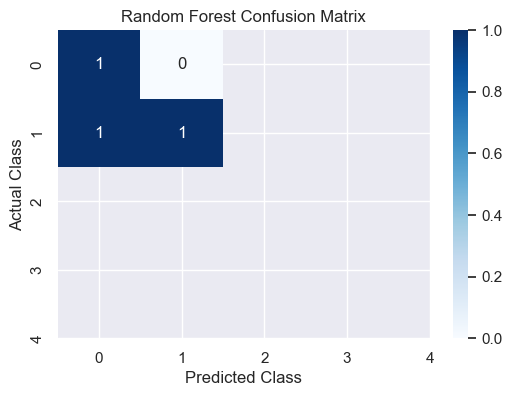

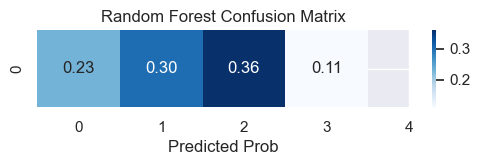

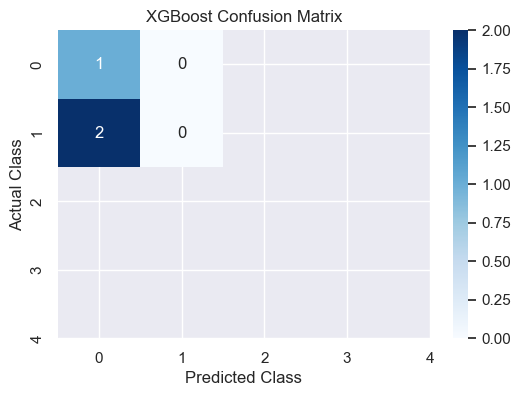

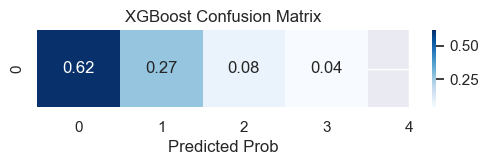

In [54]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [55]:
target = "GAC"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [56]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

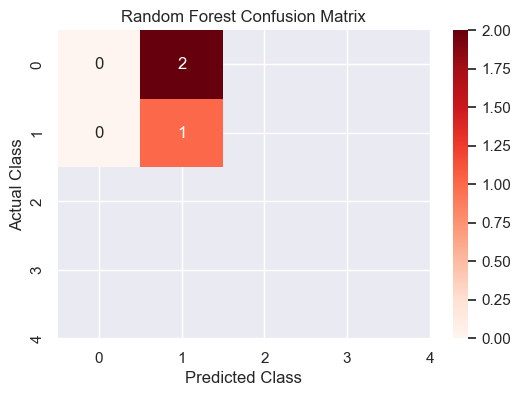

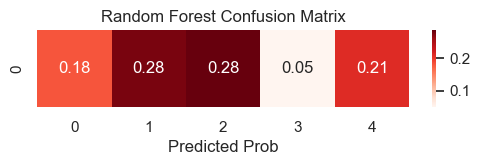

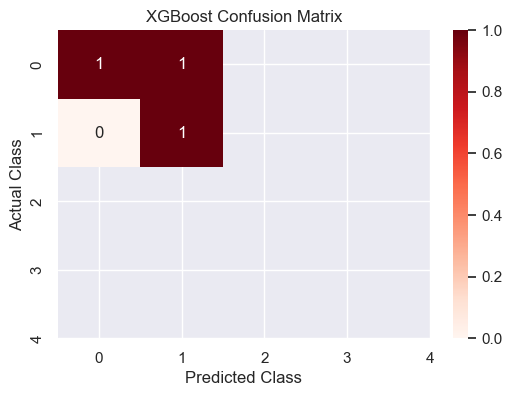

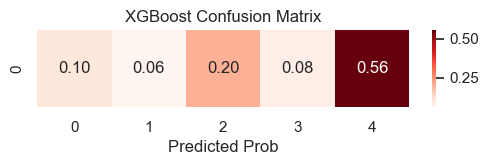

In [58]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [59]:
target = "GFC"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [60]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [61]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

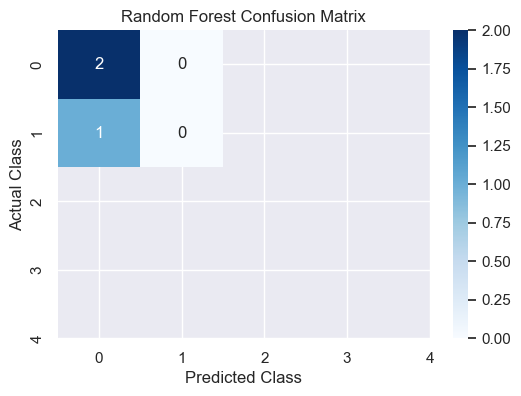

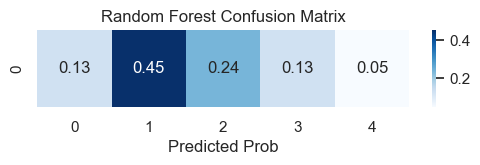

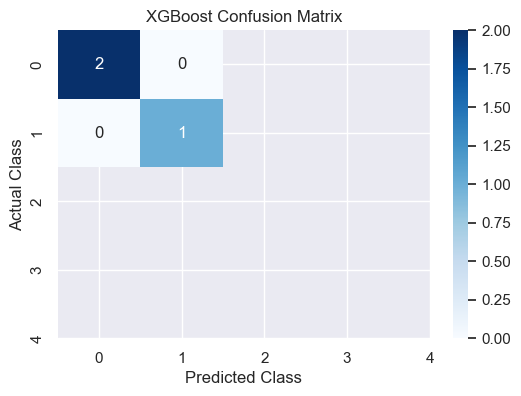

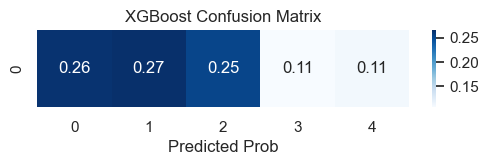

In [62]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Away

In [63]:
target = "GAC"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [64]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [65]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

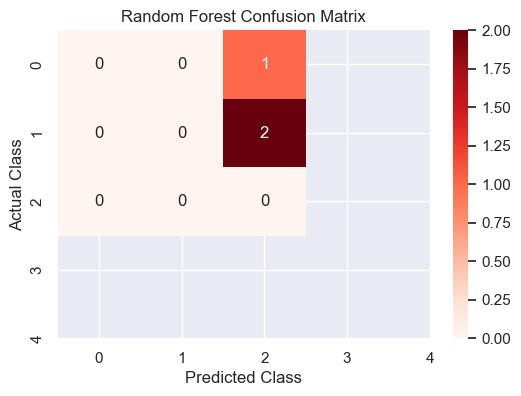

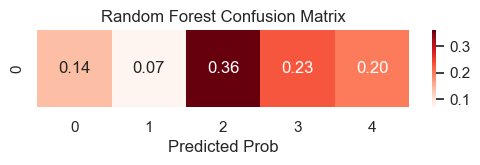

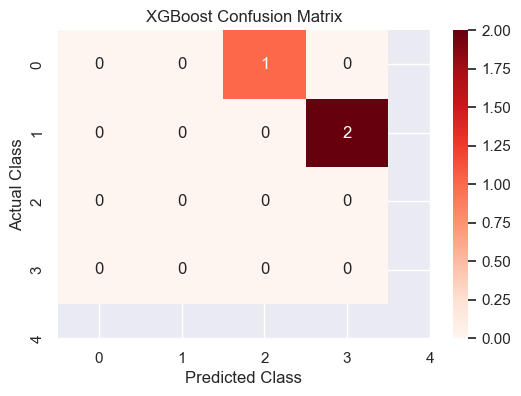

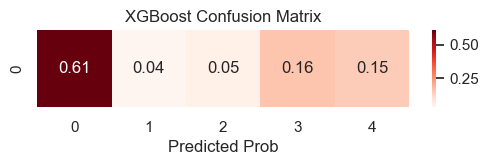

In [66]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

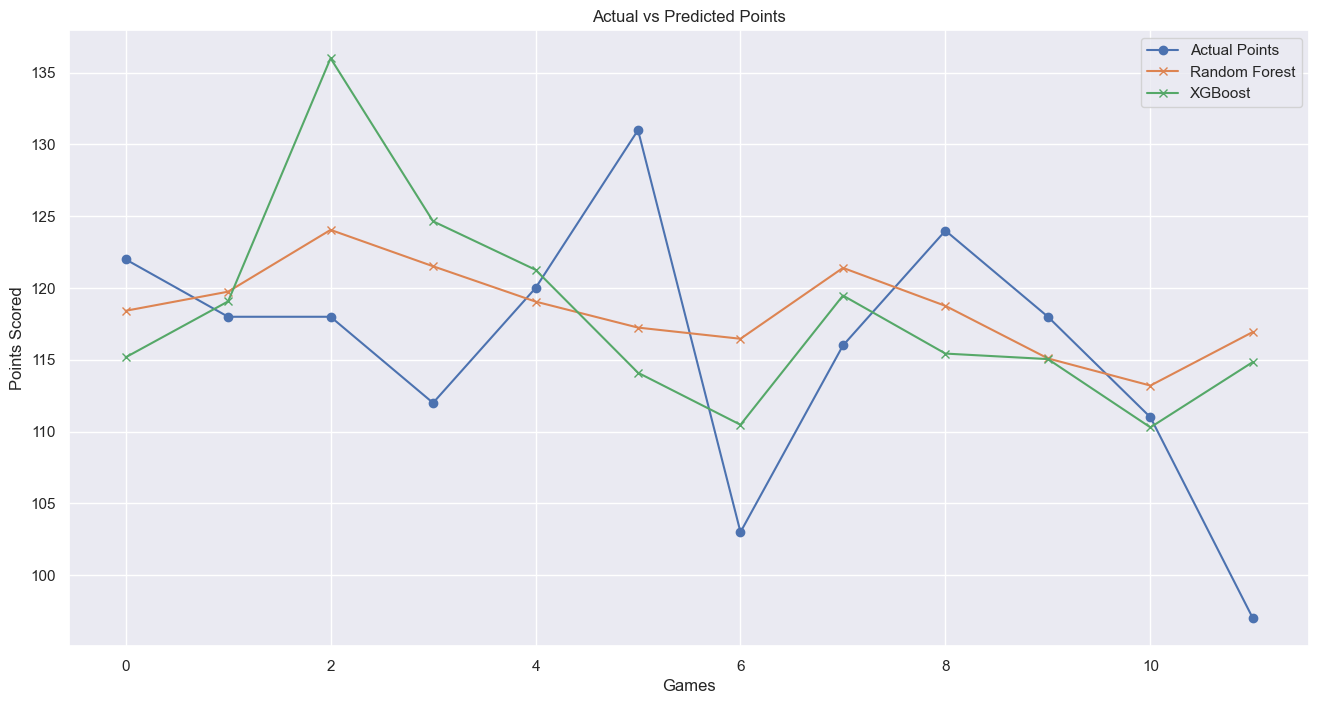

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
